In [623]:
# https://www.kaggle.com/datasets/mchilamwar/predict-concrete-strength?select=ConcreteStrengthData.csv
# https://www.edu.goit.global/uk/learn/38302462/26519706/26520566/homework

import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import root_mean_squared_error as RMSE, mean_absolute_error as MAE, mean_squared_error as MSE, r2_score as R2 

from dataclasses import dataclass

import warnings
# filter warnings
warnings.filterwarnings('ignore')

In [624]:
torch.set_default_device('cuda')

In [625]:
df = pd.read_csv('../data/ConcreteStrengthData.csv')

In [626]:
df.isna().sum()

CementComponent              0
BlastFurnaceSlag             0
FlyAshComponent              0
WaterComponent               0
SuperplasticizerComponent    0
CoarseAggregateComponent     0
FineAggregateComponent       0
AgeInDays                    0
Strength                     0
dtype: int64

In [627]:
X = df.drop('Strength', axis=1)
y = df['Strength']

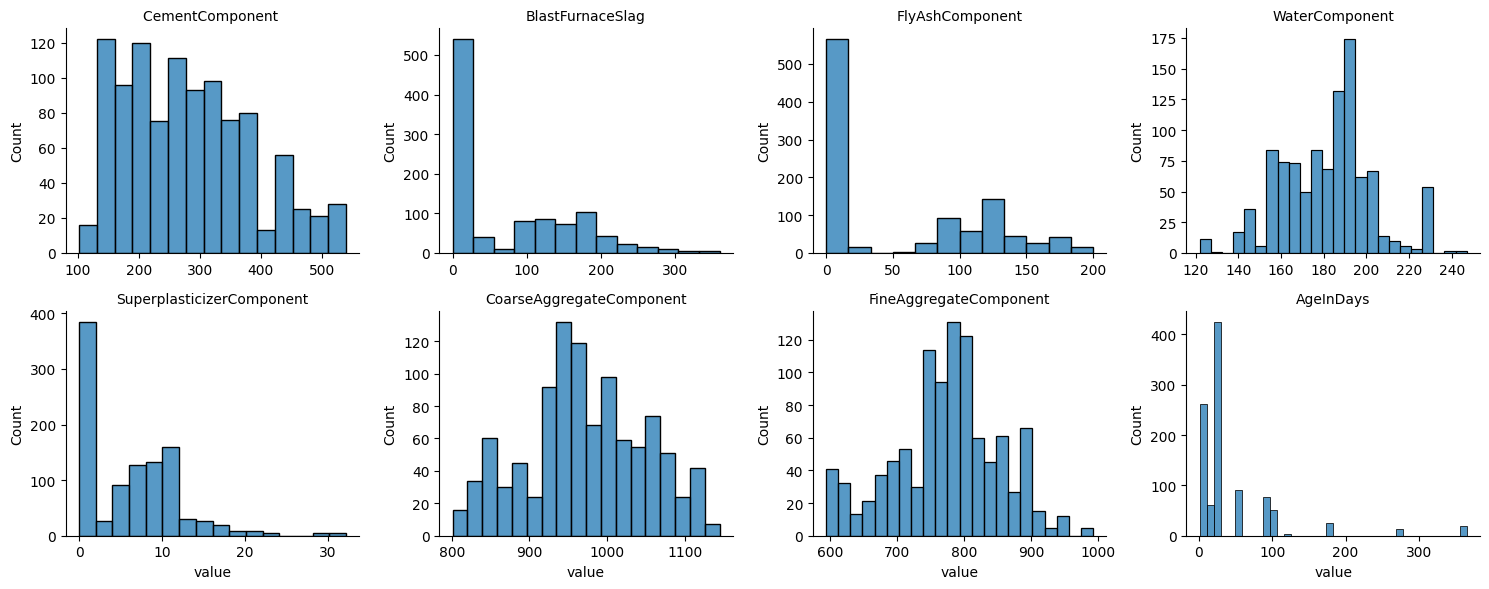

In [645]:
melted_prep = X.melt()

g = sns.FacetGrid(melted_prep,
                  col='variable',
                  col_wrap=4,
                  sharex=False,
                  sharey=False,
                  aspect=1.25)

g.map(sns.histplot, 'value')
g.set_titles(col_template='{col_name}')
g.tight_layout()
plt.show()

In [628]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.3)

In [629]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [630]:
class BigmartDataset(Dataset):
    def __init__(self, X, y, scale=True):        
        self.X = X.values
        self.y = y.values

    def __len__(self):
        #return size of a dataset
        return len(self.y)

    def __getitem__(self, idx):
        #supports indexing using dataset[i] to get the i-th row in a dataset
        
        X = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.float32)        
        
        return X, y

In [631]:
# Creating train and test datasets

train_dataset = BigmartDataset(X_train, y_train)
test_dataset = BigmartDataset(X_test, y_test)

In [632]:
# Loading Batches of Data
train_dataloader = DataLoader(train_dataset,
                              batch_size=200
                             )

test_dataloader = DataLoader(test_dataset,
                              batch_size=200
                             )

In [633]:
next(iter(train_dataloader))

[tensor([[ 194.7000,    0.0000,  100.5000,  ..., 1006.4000,  905.9000,
            28.0000],
         [ 325.0000,    0.0000,    0.0000,  ..., 1063.0000,  783.0000,
             7.0000],
         [ 318.8000,  212.5000,    0.0000,  ...,  852.1000,  880.4000,
             3.0000],
         ...,
         [ 310.0000,  142.8000,    0.0000,  ...,  914.3000,  804.0000,
            28.0000],
         [ 376.0000,    0.0000,    0.0000,  ..., 1003.5000,  762.4000,
            14.0000],
         [ 167.0000,   75.4000,  167.0000,  ..., 1007.3000,  770.1000,
             3.0000]], device='cuda:0'),
 tensor([25.7200, 17.5400, 25.2000, 23.6400, 33.7600, 13.2900, 13.3600, 51.0600,
         24.4800, 65.9100, 25.5700, 44.0300, 32.8500, 13.4600, 38.1100, 74.9900,
         79.3000, 15.5300, 46.3900, 12.1800,  9.8500, 33.7000, 23.2500, 36.4500,
         77.3000, 25.5600, 38.4600, 23.5200, 21.8600, 37.8100, 19.6900, 37.4300,
         26.0500, 38.8900, 26.1500, 11.4800, 33.0600, 15.6900, 67.3100, 28.6300,
    

In [634]:
class LinearModel(torch.nn.Module):
    def __init__(self, in_dim, out_dim=1):
        super().__init__()
        
        self.features = torch.nn.Sequential(
            nn.Linear(in_dim, 256),
            torch.nn.ReLU(),
            #torch.nn.Dropout(p=0.3),
            
            nn.Linear(256, 128),
            torch.nn.ReLU(),
            #torch.nn.Dropout(p=0.3),
            
            nn.Linear(128, 64),
            torch.nn.ReLU(),
            #torch.nn.Dropout(p=0.3),
            
            nn.Linear(64, out_dim),
        )
    
        
    def forward(self, x):
        output = self.features(x)
        return output

In [635]:
# Initialize the model
model = LinearModel(in_dim=X_train.shape[1], out_dim=1)

In [636]:
  
# Define the loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [638]:
@dataclass
class MetricResult:
    def __init__(self):
        self.losses = []
        self.rmses = []
        self.mae = []
        self.r2 = []
        self.mse = []   
    
train_result = MetricResult()
test_result = MetricResult()

In [ ]:
# Train the model

num_epochs = 150

for epoch in range(num_epochs):
    
    # Train step
    model.train()
    
    y_pred_train = []
    batch_losses = []
    for data in train_dataloader:
        # Get and prepare inputs
        inputs, targets = data
        inputs, targets = inputs.float(), targets.float()
        targets = targets.reshape((targets.shape[0], 1))
        # Forward pass
        outputs = model(inputs)
        loss_train = criterion(outputs, targets)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()
        
        y_pred_train.extend(outputs.cpu().detach().numpy())
        batch_losses.append(loss_train.item())
    
    rmse = RMSE(y_train, y_pred_train)
    mae = MAE(y_train, y_pred_train)
    r2 = R2(y_train, y_pred_train)
    mse = MSE(y_train, y_pred_train)
    
    if (epoch+1) % 10 == 0:
        print(f'TRAIN [{epoch+1}/{num_epochs}], Loss: {loss_train.item():.4f}, RMSE: {rmse:.4f},R2:{r2:.4f}, MAE:{mae:.4f},MSE:{mse:.4f}')
    
    
    train_result.rmses.append(rmse)
    train_result.mae.append(mae)
    train_result.r2.append(r2)
    train_result.mse.append(mse)

    epoch_loss = np.mean(batch_losses)
    train_result.losses.append(epoch_loss)
    
    
    # Eval step
    model.eval()
    
    y_pred_test = []
    batch_losses.clear()
    with torch.no_grad():
        
        for data in test_dataloader:
            # Get and prepare inputs
            inputs, targets = data
            inputs, targets = inputs.float(), targets.float()
            targets = targets.reshape((targets.shape[0], 1))
            # Forward pass
            outputs = model(inputs)
            loss_test = criterion(outputs, targets)
            
            # No backward pass
            
            y_pred_test.extend(outputs.cpu().detach().numpy())
            batch_losses.append(loss_test.item())
        
        rmse = RMSE(y_test, y_pred_test)
        mae = MAE(y_test, y_pred_test)
        r2 = R2(y_test, y_pred_test)
        mse = MSE(y_test, y_pred_test)
        
        if (epoch+1) % 10 == 0:
            print(f'TEST [{epoch+1}/{num_epochs}], Loss: {loss_test.item():.4f}, RMSE: {rmse:.4f},R2:{r2:.4f}, MAE:{mae:.4f},MSE:{mse:.4f}')
       
        test_result.rmses.append(rmse)
        test_result.mae.append(mae)
        test_result.r2.append(r2)
        test_result.mse.append(mse)
        
        epoch_loss = np.mean(batch_losses) 
        test_result.losses.append(epoch_loss)
       


TRAIN [10/150], Loss: 145.1995, RMSE: 11.9621,R2:0.4925, MAE:9.6005,MSE:143.0920
TEST [10/150], Loss: 159.4455, RMSE: 12.0932,R2:0.4595, MAE:9.5667,MSE:146.2452
TRAIN [20/150], Loss: 93.8896, RMSE: 9.7832,R2:0.6606, MAE:7.5472,MSE:95.7115
TEST [20/150], Loss: 107.8584, RMSE: 9.6554,R2:0.6554, MAE:7.3917,MSE:93.2273
TRAIN [30/150], Loss: 67.5747, RMSE: 8.2579,R2:0.7582, MAE:6.3032,MSE:68.1929
TEST [30/150], Loss: 80.6155, RMSE: 8.2722,R2:0.7471, MAE:6.4802,MSE:68.4285
TRAIN [40/150], Loss: 53.3862, RMSE: 7.2492,R2:0.8136, MAE:5.5575,MSE:52.5516
TEST [40/150], Loss: 69.1890, RMSE: 7.6646,R2:0.7829, MAE:5.9908,MSE:58.7456
TRAIN [50/150], Loss: 45.9811, RMSE: 6.7352,R2:0.8391, MAE:5.1508,MSE:45.3629
TEST [50/150], Loss: 59.8134, RMSE: 7.1625,R2:0.8104, MAE:5.4760,MSE:51.3009
TRAIN [60/150], Loss: 44.7160, RMSE: 6.2401,R2:0.8619, MAE:4.7353,MSE:38.9386
TEST [60/150], Loss: 57.3140, RMSE: 7.1081,R2:0.8133, MAE:5.3492,MSE:50.5256
TRAIN [70/150], Loss: 41.4698, RMSE: 6.0845,R2:0.8687, MAE:4.63

In [640]:
print(len(train_result.losses))
print(len(test_result.losses))
print(len(batch_losses))

150
150
2


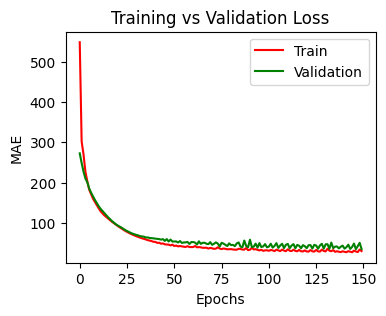

In [641]:
plt.figure(figsize=(4, 3))
plt.plot(train_result.losses, label='Train', color = 'red')
plt.plot(test_result.losses, label='Validation', color = 'green')
plt.legend(loc='best')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training vs Validation Loss')
plt.show()


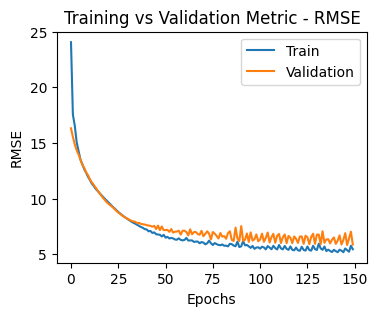

In [642]:
plt.figure(figsize=(4, 3))
plt.plot(train_result.rmses, label='Train')
plt.plot(test_result.rmses, label='Validation')
plt.legend(loc='best')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('Training vs Validation Metric - RMSE')
plt.show()

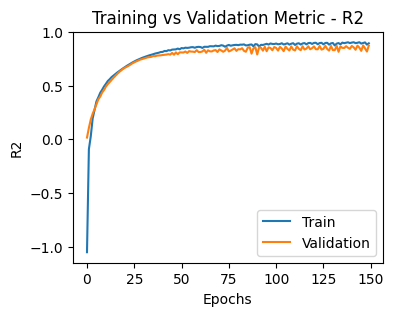

In [643]:
plt.figure(figsize=(4, 3))
plt.plot(train_result.r2, label='Train')
plt.plot(test_result.r2, label='Validation')
plt.legend(loc='best')
plt.xlabel('Epochs')
plt.ylabel('R2')
plt.title('Training vs Validation Metric - R2')
plt.show()

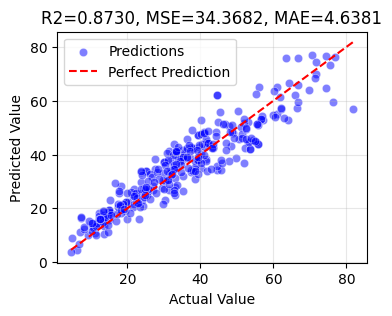

In [644]:
plt.figure(figsize=(4, 3))

sns.scatterplot(x=y_test.values, y=np.array(y_pred_test).flatten(), alpha=0.5, color="blue", label="Predictions")
sns.lineplot(x=[min(y_test), max(y_test)], y=[min(y_test), max(y_test)], color='red', linestyle="--", label="Perfect Prediction")

plt.title(f'R2={test_result.r2[-1]:.4f}, MSE={test_result.mse[-1]:.4f}, MAE={test_result.mae[-1]:.4f}')
plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Висновок: в цьому завданні ми намагались побудувать просту нейронну мережу для задачі регресії. Структура моделі представлена в конспекті показала себе добре - тому було вирішено її взяти за основу. Спроби додати або змінити шари(напр. Dropout) особливо нічого не дали.  
Модель оцінювалась за 3 метриками R2, MAE, MSE - за цими метриками модель показала себе задовільно. 
